In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
X=np.array([[1,2],[2,3],[3,3],[6,5],[7,7],[8,6]])
y=np.array([0,0,0,1,1,1])
k=3 #No. of nearest neighbors
knn=KNeighborsClassifier(n_neighbors=k)
knn.fit(X,y)
sample=np.array([[1,5]])
pred_class=knn.predict(sample)
print("Predicted class for [1,5]:",pred_class)

Predicted class for [1,5]: [0]


In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv("btissue.csv")
print(df.head())
print(df.info())
print("\n MIssing values per column:")
print(df.isnull().sum())
print("\n--- Summary Stastics---")
print(df.describe())

           I0     PA500       HFS          DA          Area       A/DA  \
0  524.794072  0.187448  0.032114  228.800228   6843.598481  29.910803   
1  330.000000  0.226893  0.265290  121.154201   3163.239472  26.109202   
2  551.879287  0.232478  0.063530  264.804935  11888.391830  44.894903   
3  380.000000  0.240855  0.286234  137.640111   5402.171180  39.248524   
4  362.831266  0.200713  0.244346  124.912559   3290.462446  26.342127   

      Max IP          DR           P class  
0  60.204880  220.737212  556.828334   car  
1  69.717361   99.084964  400.225776   car  
2  77.793297  253.785300  656.769449   car  
3  88.758446  105.198568  493.701814   car  
4  69.389389  103.866552  424.796503   car  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I0      106 non-null    float64
 1   PA500   106 non-null    float64
 2   HFS     106 non-null    flo

In [3]:
X=df.iloc[:, :-1].values
y=df.iloc[:, -1].values
print("\nFeature shape:",X.shape)
print("\nTarget shape:",y.shape)


Feature shape: (106, 9)

Target shape: (106,)


In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=123)
print("\nTrain Shape:",X_train.shape)
print("\nTest Shape:",X_test.shape)


Train Shape: (74, 9)

Test Shape: (32, 9)



KNN Results:
Accuracy: 0.46875
Precision: 0.34289321789321786
Recall: 0.4174603174603175
F1-score: 0.3702686202686203

Confusion Matrix:
 [[5 0 2 0 0 0]
 [0 6 1 0 0 0]
 [1 1 1 0 0 0]
 [0 1 0 0 1 4]
 [0 1 0 3 0 0]
 [0 2 0 0 0 3]]


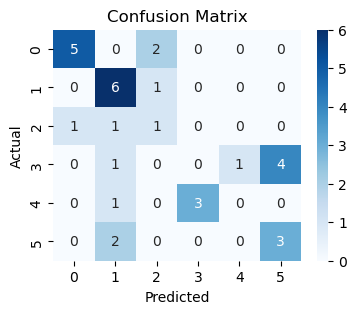

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Train model
knn = KNeighborsClassifier(n_neighbors=3)
model = knn.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nKNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='macro', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='macro', zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



---Decision Tree Res---
Accuracy: 0.46875
Precision: 0.34289321789321786
Recall: 0.4174603174603175
F1-score: 0.3702686202686203

Confusion Matrix:
 [[5 0 2 0 0 0]
 [0 6 1 0 0 0]
 [1 1 1 0 0 0]
 [0 1 0 0 1 4]
 [0 1 0 3 0 0]
 [0 2 0 0 0 3]]


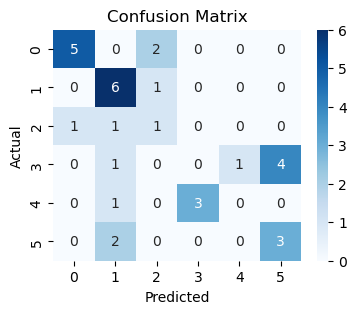

In [6]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
model=dt.fit(X_train,y_train)
y_pred_dt=model.predict(X_test)
print("\n---Decision Tree Res---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='macro', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, average='macro', zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



----RF Results----
Accuracy: 0.65625
Precision: 0.7866161616161617
Recall: 0.6456349206349207
F1-score: 0.6120472120472119


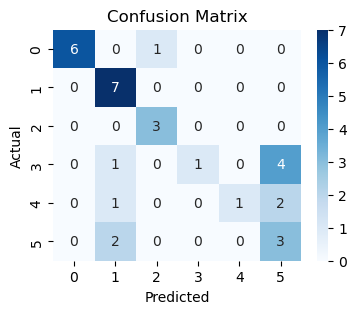

In [8]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
model=rf.fit(X_train,y_train)
y_pred_rf=model.predict(X_test)
print("\n----RF Results----")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='macro', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, average='macro', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_rf, average='macro', zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
# Plot confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


----SVM Results----
Accuracy: 0.375
Precision: 0.2916666666666667
Recall: 0.3333333333333333
F1-score: 0.23877995642701522


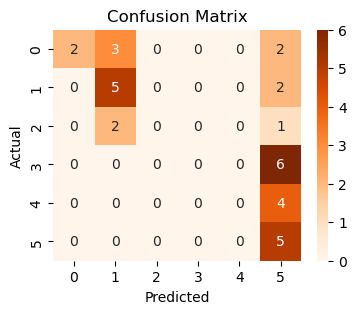

In [12]:
from sklearn.svm import SVC
svm=SVC(kernel='rbf',random_state=42)
model=svm.fit(X_train,y_train)
y_pred_svm=model.predict(X_test)
print("\n----SVM Results----")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='macro', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_svm, average='macro', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_svm, average='macro', zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)
# Plot confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()